[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Truss with a combination of loads

Last updated: 07/13/26

## Problem description

A truss with a combination of loads. The truss is supported at three joints, and
one of those supports is inclined. This tutorial demonstrates how to use a
combination of loads.

## References

Original source: "Guide de validation des progiciels de calcul de structures"
publié par l'AFNOR 1990 (ISBN 2-12-486611-7).

Data taken from: ICAB Force Exemples Exemples de calculs de statique pour ICAB
Force. www.icab.fr

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


In [96]:
from math import pi, cos, sin
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import geometry
from pystran import plots

US SI(m) units are implied.


In [97]:
E = 2.1e11  # Pa
CTE = 1.0e-5  # 1/degC
A1 = 1.41e-3  # m^2
A2 = 2 * 1.41e-3  # m^2


The rigid support is a bar of unit length, and artificially increased 
cross sectional area.


In [98]:
Ar = 1.0e5  # m^2
cth = cos(60 / 180 * pi)
sth = sin(60 / 180 * pi)


Increase of temperature above reference. All bars are affected, except the one
used as a rigid support.


In [99]:
DeltaT = 150.0

Create the model by defining joints and truss members.


In [100]:
m = model.create(2)
freedoms = m["freedoms"]

In [101]:
model.add_joint(m, 1, [0.0, 0.0])  # A
model.add_joint(m, 2, [0.0, 4.0])
model.add_joint(m, 3, [5.0, 0.0])
model.add_joint(m, 4, [2 * 5.0, 4.0])
model.add_joint(m, 5, [3 * 5.0, 0.0])
model.add_joint(m, 6, [4 * 5.0, 4.0])
model.add_joint(m, 7, [5 * 5.0, 0.0])  # D - monitored joint
model.add_joint(m, 8, [6 * 5.0, 4.0])
model.add_joint(m, 9, [7 * 5.0, 0.0])  # C
model.add_joint(m, 10, [4 * 5.0, -4.0])  # B


{'jid': 10, 'coordinates': array([20., -4.])}

The direction of the inclined support is defined by the angle 30 degrees of
the plane on which the joint can slide. C' is the joint that is pinned, and C
is the joint whose motion is controlled.


In [102]:
model.add_joint(m, 11, [7 * 5.0 + 1.0 * cth, 0.0 - 1.0 * sth])  # C'

{'jid': 11, 'coordinates': array([35.5      , -0.8660254])}

Define the truss sections for two groups of bars.


In [103]:
s1 = section.truss_section("s1", E=E, A=A1, CTE=CTE)
s2 = section.truss_section("s2", E=E, A=A2, CTE=CTE)


Group 1.


In [104]:
model.add_truss_member(m, 1, [1, 2], s1)
model.add_truss_member(m, 2, [2, 3], s1)
model.add_truss_member(m, 3, [3, 4], s1)
model.add_truss_member(m, 4, [4, 5], s1)
model.add_truss_member(m, 5, [5, 6], s1)
model.add_truss_member(m, 6, [6, 7], s1)
model.add_truss_member(m, 7, [7, 8], s1)
model.add_truss_member(m, 8, [8, 9], s1)

{'mid': 8,
 'connectivity': [8, 9],
 'section': {'name': 's1',
  'E': 210000000000.0,
  'rho': 0.0,
  'CTE': 1e-05,
  'A': 0.00141}}

Group 2.


In [105]:
model.add_truss_member(m, 11, [2, 4], s2)
model.add_truss_member(m, 12, [4, 6], s2)
model.add_truss_member(m, 13, [6, 8], s2)
model.add_truss_member(m, 14, [1, 3], s2)
model.add_truss_member(m, 15, [3, 5], s2)
model.add_truss_member(m, 16, [5, 10], s2)
model.add_truss_member(m, 17, [10, 7], s2)
model.add_truss_member(m, 18, [7, 9], s2)
model.add_truss_member(m, 19, [10, 6], s2)

{'mid': 19,
 'connectivity': [10, 6],
 'section': {'name': 's2',
  'E': 210000000000.0,
  'rho': 0.0,
  'CTE': 1e-05,
  'A': 0.00282}}

Define the section of the bar used as a rigid support. Note that it does not
thermally expand since its coefficient of thermal expansion is set to zero.


In [106]:
sr = section.truss_section("sr", E=E, A=Ar, CTE=0.0)

Finally,

In [107]:
model.add_truss_member(m, 20, [9, 11], sr)

{'mid': 20,
 'connectivity': [9, 11],
 'section': {'name': 'sr',
  'E': 210000000000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 100000.0}}

Inspect the base structure visually.


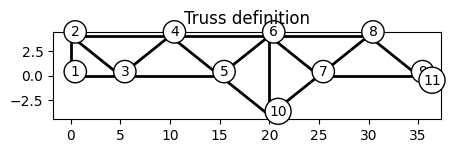

In [108]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_members(m)
ax.set_title("Truss definition")
plots.show(m)

Add the supports and loads. We will do that in three load cases. The quantity
we are interested in is displacement of the joint 7 (D) in the y-direction.

A helper function to set up the thermal load is defined to simplify its application.


In [109]:
def add_thermal_loads(_m):
    """Set up thermal loads."""
    for member in _m["truss_members"].values():
        if member["mid"] != 20:
            sect = member["section"]
            EA = sect["E"] * sect["A"]
            _CTE = sect["CTE"]
            connectivity = member["connectivity"]
            _i, _j = _m["joints"][connectivity[0]], _m["joints"][connectivity[1]]
            d = geometry.delt(_i["coordinates"], _j["coordinates"])
            nd = d / norm(d)
            N_T = _CTE * DeltaT * EA
            model.add_load(_i, freedoms.U1, -nd[0] * N_T)
            model.add_load(_i, freedoms.U2, -nd[1] * N_T)
            model.add_load(_j, freedoms.U1, +nd[0] * N_T)
            model.add_load(_j, freedoms.U2, +nd[1] * N_T)

Load case 1: concentrated forces, homogeneous (all components set to zero)
supports.

We begin by clearing all loads and supports.


In [110]:
model.remove_loads(m)
model.remove_supports(m)

Then we add concentrated forces.


In [111]:
model.add_load(m["joints"][4], freedoms.U2, -150.0e3)
model.add_load(m["joints"][8], freedoms.U2, -100.0e3)

And we add homogeneous (zero-displacement) supports.


In [112]:
model.add_support(m["joints"][1], freedoms.U1)
model.add_support(m["joints"][1], freedoms.U2)
model.add_support(m["joints"][10], freedoms.U2)
model.add_support(m["joints"][11], freedoms.U1)
model.add_support(m["joints"][11], freedoms.U2)

The solution for the load case is obtained.


In [113]:
model.number_dofs(m)
model.solve_statics(m)

Store the displacement of the joint 7 (D) in the y-direction.


In [114]:
j = m["joints"][7]
UD1 = j["displacements"][freedoms.U2]
print("Case 1: joint 7 (D) vertical displacement", ": ", j["displacements"])

Case 1: joint 7 (D) vertical displacement :  [0.00221878 0.00051413]


Load case 2: support settlement. In this case only the supports are modified to prescribed non zero displacements.

In [115]:
model.remove_loads(m)
model.remove_supports(m)

In [116]:
model.add_support(m["joints"][1], freedoms.U1)
model.add_support(m["joints"][1], freedoms.U2, -0.02)
model.add_support(m["joints"][10], freedoms.U2, -0.03)
model.add_support(m["joints"][11], freedoms.U1, +0.015 * cth)
model.add_support(m["joints"][11], freedoms.U2, -0.015 * sth)

In [117]:
model.number_dofs(m)
model.solve_statics(m)

Now we retrieve the solution for the prescribed displacements.

In [118]:
j = m["joints"][7]
UD2 = j["displacements"][freedoms.U2]
print("Case 2: joint 7 (D) vertical displacement", ": ", j["displacements"])

Case 2: joint 7 (D) vertical displacement :  [ 0.00231082 -0.02830709]


Load case 3: thermal loads, homogeneous supports.

All loads and supports are cleared.


In [119]:
model.remove_loads(m)
model.remove_supports(m)

Homogeneous displacement supports are added.


In [120]:
model.add_support(m["joints"][1], freedoms.U1)
model.add_support(m["joints"][1], freedoms.U2)
model.add_support(m["joints"][10], freedoms.U2)
model.add_support(m["joints"][11], freedoms.U1)
model.add_support(m["joints"][11], freedoms.U2)

Thermal loads are added.


In [121]:
add_thermal_loads(m)

In [122]:
model.number_dofs(m)
model.solve_statics(m)

Retrieve the solution for the thermal load case.

In [123]:
j = m["joints"][7]
UD3 = j["displacements"][freedoms.U2]
print("Case 3: joint 7 (D) vertical displacement", ": ", j["displacements"])

Case 3: joint 7 (D) vertical displacement :  [0.03976861 0.01161632]


In [124]:
print("Displacement of D for the load combination: ", UD1 + UD2 + UD3)
print("Displacement of D reference: ", -0.01618)

Displacement of D for the load combination:  -0.01617664504146328
Displacement of D reference:  -0.01618


Now we combine the solutions for the three load cases.

In [125]:
if abs(UD1 + UD2 + UD3 + 0.01618) > 1.0e-4:
    raise ValueError("Displacement of D incorrect.")

Now we intend to check that the load combination will lead to the same result
as all loadings applied at once.

Load cases combined into one: all loadings are applied in a single load case.

In [126]:
model.remove_loads(m)
model.remove_supports(m)

Non zero displacements.


In [127]:
model.add_support(m["joints"][1], freedoms.U1)
model.add_support(m["joints"][1], freedoms.U2, -0.02)
model.add_support(m["joints"][10], freedoms.U2, -0.03)
model.add_support(m["joints"][11], freedoms.U1, +0.015 * cth)
model.add_support(m["joints"][11], freedoms.U2, -0.015 * sth)

Concentrated forces.


In [128]:
model.add_load(m["joints"][4], freedoms.U2, -150.0e3)
model.add_load(m["joints"][8], freedoms.U2, -100.0e3)

Thermal loads.


In [129]:
add_thermal_loads(m)

In [130]:
model.number_dofs(m)
model.solve_statics(m)

In [131]:
j = m["joints"][7]
UD = j["displacements"][freedoms.U2]
print("Combined loading: joint 7 (D) vertical displacement", ": ", j["displacements"])

Combined loading: joint 7 (D) vertical displacement :  [ 0.04429822 -0.01617665]


Check that the load combination will gave the same displacement as all the
loadings combined.

In [132]:
if abs(UD - (UD1 + UD2 + UD3)) > 1.0e-9:
    raise ValueError("Displacement of D incorrect.")

Finally, display the deformed truss.


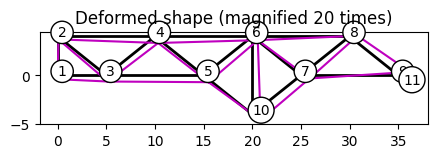

In [133]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_joint_ids(m)
ax = plots.plot_deformations(m, 20.0)
ax.set_title("Deformed shape (magnified 20 times)")
plots.show(m)

## Conclusions

Here we illustrate the simple principle of superposition of solutions of systems of linear equations.